# PANAGEA exploration 2 — Chlorophyll-a patterns

Distribution of chlorophyll-a, the agreement between the two measurement
methods (HPLC vs fluorometric/spectrophotometric), and the large-scale
latitudinal and seasonal structure.

Findings are summarised at the bottom.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ocpy.insitu import panagea

chla = panagea.load('chla')
chl = chla['chla_hplc'].fillna(chla['chla_fluor'])
print('chl observations:', chl.notna().sum())

chl observations: 82543


## Distribution (log scale)

Chlorophyll spans several orders of magnitude, so we look at log10.

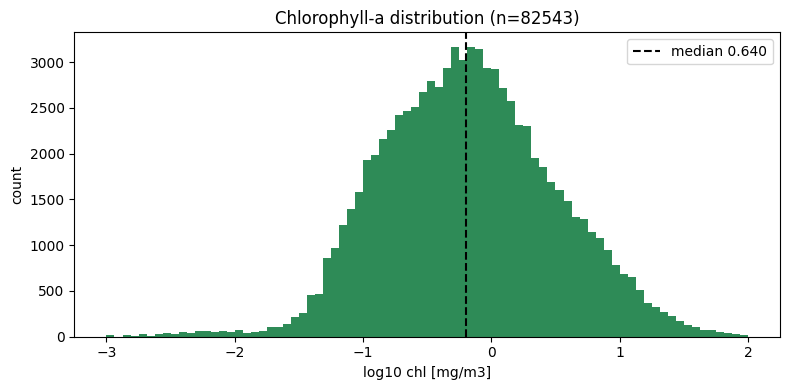

range 0.0010 .. 100.00  median 0.640


In [2]:
v = chl[(chl > 0)].dropna()
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(np.log10(v), bins=80, color='seagreen')
ax.set_xlabel('log10 chl [mg/m3]'); ax.set_ylabel('count')
ax.set_title('Chlorophyll-a distribution (n=%d)' % len(v))
ax.axvline(np.log10(v.median()), color='k', ls='--',
           label='median %.3f' % v.median())
ax.legend()
plt.tight_layout(); plt.show()
print('range %.4f .. %.2f  median %.3f' % (v.min(), v.max(), v.median()))

The distribution is approximately log-normal — the expected shape for
open-ocean chlorophyll — centred near 0.6 mg/m3.

## HPLC vs fluorometric agreement

Where an observation has *both* methods, how well do they agree?

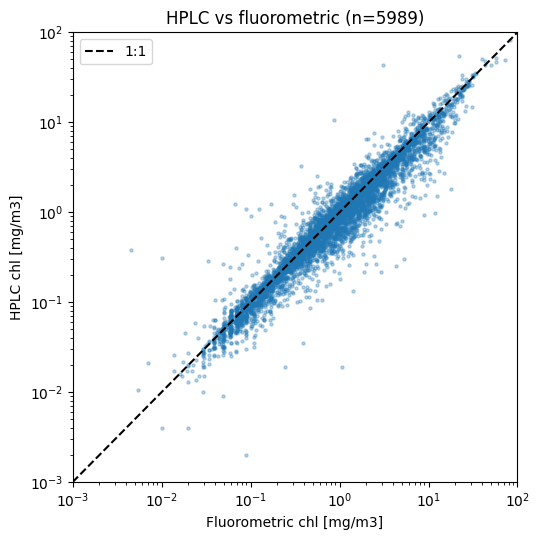

median log10(HPLC/Fluor)=-0.026  -> ratio 0.943
scatter (std of log10 ratio)=0.172


In [3]:
both = chla.dropna(subset=['chla_hplc', 'chla_fluor'])
both = both[(both['chla_hplc'] > 0) & (both['chla_fluor'] > 0)]
lr = np.log10(both['chla_hplc'] / both['chla_fluor'])

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(both['chla_fluor'], both['chla_hplc'], s=5, alpha=0.3)
lims = [1e-3, 1e2]
ax.plot(lims, lims, 'k--', label='1:1')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('Fluorometric chl [mg/m3]')
ax.set_ylabel('HPLC chl [mg/m3]')
ax.set_title('HPLC vs fluorometric (n=%d)' % len(both))
ax.legend()
plt.tight_layout(); plt.show()
print('median log10(HPLC/Fluor)=%.3f  -> ratio %.3f' %
      (lr.median(), 10 ** lr.median()))
print('scatter (std of log10 ratio)=%.3f' % lr.std())

## Latitudinal structure

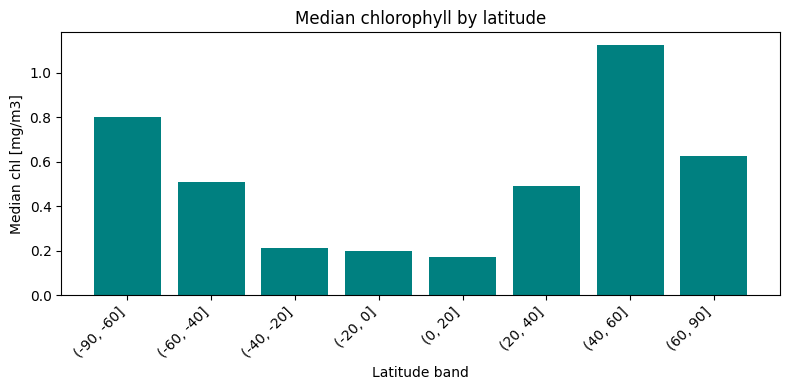

band
(-90, -60]    0.799
(-60, -40]    0.508
(-40, -20]    0.210
(-20, 0]      0.199
(0, 20]       0.170
(20, 40]      0.490
(40, 60]      1.125
(60, 90]      0.626
Name: chl, dtype: float64

In [4]:
d = pd.DataFrame({'lat': chla['lat'], 'chl': chl}).dropna()
d = d[d['chl'] > 0]
bins = [-90, -60, -40, -20, 0, 20, 40, 60, 90]
d['band'] = pd.cut(d['lat'], bins)
med = d.groupby('band', observed=True)['chl'].median()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar([str(b) for b in med.index], med.values, color='teal')
ax.set_ylabel('Median chl [mg/m3]'); ax.set_xlabel('Latitude band')
ax.set_title('Median chlorophyll by latitude')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()
med.round(3)

## Seasonal cycle (Northern Hemisphere, > 20N)

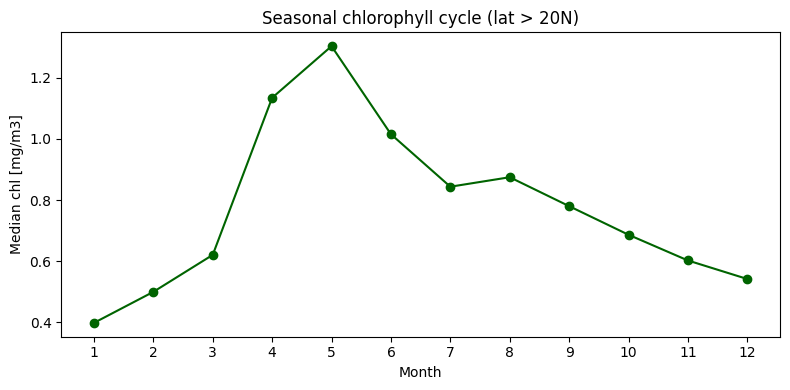

month
1     0.399
2     0.500
3     0.621
4     1.134
5     1.303
6     1.015
7     0.844
8     0.874
9     0.780
10    0.687
11    0.602
12    0.542
Name: chl, dtype: float64

In [5]:
nh = pd.DataFrame({'lat': chla['lat'], 'chl': chl,
                   'month': chla['date_time'].dt.month}).dropna()
nh = nh[(nh['lat'] > 20) & (nh['chl'] > 0)]
by_month = nh.groupby('month')['chl'].median()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(by_month.index, by_month.values, 'o-', color='darkgreen')
ax.set_xlabel('Month'); ax.set_ylabel('Median chl [mg/m3]')
ax.set_title('Seasonal chlorophyll cycle (lat > 20N)')
ax.set_xticks(range(1, 13))
plt.tight_layout(); plt.show()
by_month.round(3)

## Findings — chlorophyll

* **Log-normal, ~0.64 mg/m3 median.** Chl spans roughly 0.001-100 mg/m3 and
  is close to log-normal, as expected for a global mix of oligotrophic and
  productive waters.
* **The two methods agree well.** Where both HPLC and fluorometric values
  exist (~6k points), the median ratio HPLC/fluorometric is ~0.94 (i.e.
  fluorometric reads a few percent higher on average) with a log-scatter of
  ~0.17 dex (about a factor of 1.5). No large systematic bias.
* **Clear latitudinal gradient.** Median chl is lowest in the subtropical
  gyres (~0.17 mg/m3 between 0-20deg) and highest at productive mid-to-high
  latitudes (~1.1 mg/m3 at 40-60N), with the Southern Ocean also elevated.
* **Textbook spring bloom.** In the Northern Hemisphere the seasonal cycle
  peaks in April-May (~1.1-1.3 mg/m3) and bottoms out in winter
  (~0.4 mg/m3) — the classic temperate spring bloom signal.